In [3]:
import re

def analyze_fedcc_logs(file_path, malicious_clients=None):
    if malicious_clients is None:
        malicious_clients = [1, 2, 5]
        
    trust_counts = {c: 0 for c in malicious_clients}
    total_rounds = 0
    in_target_section = False
    
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                # 1. Isolate the Test 2 FedCC Attack section
                if "Test 2" in line and "FedCC" in line and "attack" in line.lower():
                    in_target_section = True
                    continue
                
                if not in_target_section:
                    continue
                    
                # 2. Count the rounds (every time it prints cluster sizes)
                if "[FedCC] Cluster sizes:" in line:
                    total_rounds += 1
                    
                # 3. Look for the TRUSTED status and extract the Client ID
                if "TRUSTED" in line:
                    match = re.search(r"Client\s+(\d+)", line)
                    if match:
                        client_id = int(match.group(1))
                        # If the trusted client is one of our attackers, count it
                        if client_id in malicious_clients:
                            trust_counts[client_id] += 1

        # Format the output report
        print("=" * 50)
        print(f" FEDCC ATTACK ANALYSIS: {file_path}")
        print("=" * 50)
        
        if total_rounds == 0:
            print("ERROR: Could not find any FedCC attack rounds in the file.")
            return

        print(f"Total Rounds Analyzed: {total_rounds}")
        print("-" * 50)
        
        for client_id in malicious_clients:
            count = trust_counts[client_id]
            percentage = (count / total_rounds) * 100
            print(f"Client {client_id} (Malicious) | Trusted: {count:2d} times | Bypass Rate: {percentage:5.1f}%")
            
        print("=" * 50)
        print() # Add spacing between reports

    except FileNotFoundError:
        print(f"Error: Could not find the file {file_path}")

# Run the analysis on both files
analyze_fedcc_logs('fedCC-class1.txt')
analyze_fedcc_logs('fedCC-class2.txt')

 FEDCC ATTACK ANALYSIS: fedCC-class1.txt
Total Rounds Analyzed: 50
--------------------------------------------------
Client 1 (Malicious) | Trusted: 46 times | Bypass Rate:  92.0%
Client 2 (Malicious) | Trusted: 36 times | Bypass Rate:  72.0%
Client 5 (Malicious) | Trusted:  2 times | Bypass Rate:   4.0%

 FEDCC ATTACK ANALYSIS: fedCC-class2.txt
Total Rounds Analyzed: 50
--------------------------------------------------
Client 1 (Malicious) | Trusted: 22 times | Bypass Rate:  44.0%
Client 2 (Malicious) | Trusted: 37 times | Bypass Rate:  74.0%
Client 5 (Malicious) | Trusted: 19 times | Bypass Rate:  38.0%



In [5]:
import re

def analyse_attacker_evasion(log_text, attack_clients=None, test_section='Test 2  - Attack | Strategy: SignGuard', file_label=""):
    if attack_clients is None:
        attack_clients = [1, 2, 5]
        
    # Extract the relevant section
    try:
        section = log_text.split(test_section)[1]
    except IndexError:
        print(f"Error: Could not find the attack section in {file_label}")
        return {}
    
    trust_counts = {c: 0 for c in attack_clients}
    rounds_trusted = {c: [] for c in attack_clients}
    total_rounds = 0
    rounds_with_any = 0
    rounds_with_all = 0

    for line in section.splitlines():
        m = re.search(r'Trusted clients:\s*\[([^\]]+)\]', line)
        if m:
            total_rounds += 1
            trusted = [int(x.strip()) for x in m.group(1).split(',')]
            
            any_attacker = False
            all_attackers = True
            
            for c in attack_clients:
                if c in trusted:
                    trust_counts[c] += 1
                    rounds_trusted[c].append(total_rounds)
                    any_attacker = True
                else:
                    all_attackers = False
            
            if any_attacker:
                rounds_with_any += 1
            if all_attackers:
                rounds_with_all += 1

    # --- UPDATED TO MATCH FEDCC FORMAT ---
    print("=" * 50)
    label_str = f": {file_label}" if file_label else ""
    print(f" SIGNGUARD ATTACK ANALYSIS{label_str} ")
    print("=" * 50)
    
    if total_rounds == 0:
        print("ERROR: Could not find any SignGuard attack rounds.")
        return {}

    print(f"Total Rounds Analyzed: {total_rounds}")
    print("-" * 50)
    
    for client_id in attack_clients:
        count = trust_counts[client_id]
        percentage = (count / total_rounds) * 100 if total_rounds > 0 else 0
        print(f"Client {client_id} (Malicious) | Trusted: {count:2d} times | Bypass Rate: {percentage:5.1f}%")
        
    print("=" * 50)
    print() # Add spacing between outputs
    
    # Still returning your extended metrics if you need them in variables!
    return {
        'total_rounds': total_rounds,
        'trust_counts': trust_counts,
        'rounds_trusted': rounds_trusted,
        'rounds_with_any': rounds_with_any,
        'rounds_with_all': rounds_with_all
    }

# --- Execution ---

with open('SG-class1-logs.txt') as f:
    log_text = f.read()
results1 = analyse_attacker_evasion(log_text, file_label="Targeted classes=1")

with open('SG-class2-logs.txt') as f:
    log_text = f.read()
results2 = analyse_attacker_evasion(log_text, file_label="Targeted classes=2")

 SIGNGUARD ATTACK ANALYSIS: Targeted classes=1 
Total Rounds Analyzed: 50
--------------------------------------------------
Client 1 (Malicious) | Trusted: 31 times | Bypass Rate:  62.0%
Client 2 (Malicious) | Trusted: 28 times | Bypass Rate:  56.0%
Client 5 (Malicious) | Trusted: 25 times | Bypass Rate:  50.0%

 SIGNGUARD ATTACK ANALYSIS: Targeted classes=2 
Total Rounds Analyzed: 50
--------------------------------------------------
Client 1 (Malicious) | Trusted: 25 times | Bypass Rate:  50.0%
Client 2 (Malicious) | Trusted: 21 times | Bypass Rate:  42.0%
Client 5 (Malicious) | Trusted: 14 times | Bypass Rate:  28.0%



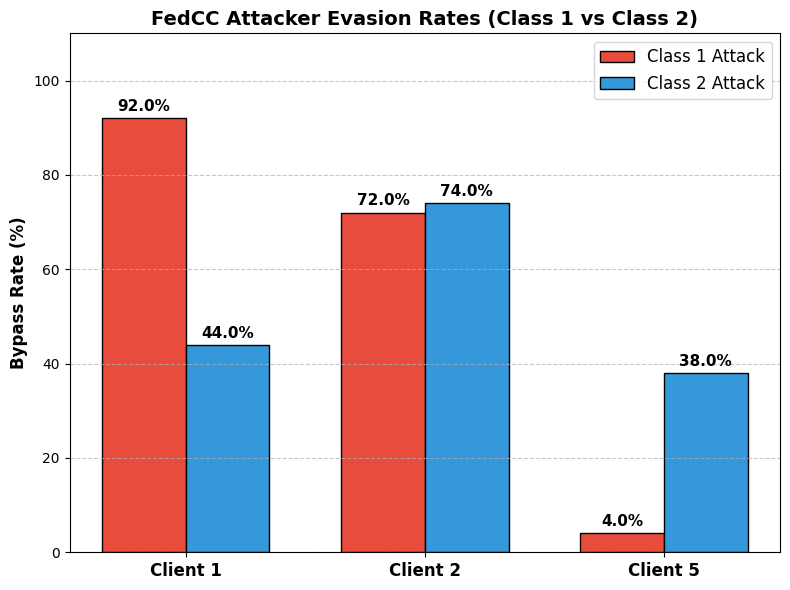

In [6]:
import re
import matplotlib.pyplot as plt
import numpy as np

def parse_fedcc_logs_for_plot(file_path, malicious_clients=None):
    """
    Parses the logs and returns the raw data (trust counts and total rounds) 
    instead of just printing it, so it can be used for plotting.
    """
    if malicious_clients is None:
        malicious_clients = [1, 2, 5]
        
    trust_counts = {c: 0 for c in malicious_clients}
    total_rounds = 0
    in_target_section = False
    
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                # 1. Isolate the Test 2 FedCC Attack section
                if "Test 2" in line and "FedCC" in line and "attack" in line.lower():
                    in_target_section = True
                    continue
                
                if not in_target_section:
                    continue
                    
                # 2. Count the rounds (every time it prints cluster sizes)
                if "[FedCC] Cluster sizes:" in line:
                    total_rounds += 1
                    
                # 3. Look for the TRUSTED status and extract the Client ID
                if "TRUSTED" in line:
                    match = re.search(r"Client\s+(\d+)", line)
                    if match:
                        client_id = int(match.group(1))
                        # If the trusted client is one of our attackers, count it
                        if client_id in malicious_clients:
                            trust_counts[client_id] += 1

        return trust_counts, total_rounds

    except FileNotFoundError:
        print(f"Error: Could not find the file {file_path}")
        return None, None

def plot_evasion_rates(class1_file, class2_file):
    """
    Takes the two log files, extracts their bypass rates, 
    and generates a clean, side-by-side grouped bar chart.
    """
    # 1. Get the data
    res_c1, rounds_c1 = parse_fedcc_logs_for_plot(class1_file)
    res_c2, rounds_c2 = parse_fedcc_logs_for_plot(class2_file)
    
    # Safety check
    if not res_c1 or not res_c2:
        print("Missing data. Cannot plot.")
        return

    clients = [1, 2, 5]
    
    # Calculate percentages
    rates_c1 = [(res_c1.get(c, 0) / rounds_c1) * 100 for c in clients]
    rates_c2 = [(res_c2.get(c, 0) / rounds_c2) * 100 for c in clients]
    
    # 2. Setup the Plotting variables
    x = np.arange(len(clients))  # Label locations
    width = 0.35                 # Width of the bars
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 3. Plot the Grouped Bars
    rects1 = ax.bar(x - width/2, rates_c1, width, label='Class 1 Attack', color='#e74c3c', edgecolor='black')
    rects2 = ax.bar(x + width/2, rates_c2, width, label='Class 2 Attack', color='#3498db', edgecolor='black')
    
    # 4. Add formatting, titles, and labels
    ax.set_ylabel('Bypass Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('FedCC Attacker Evasion Rates (Class 1 vs Class 2)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Client {c}' for c in clients], fontsize=12, fontweight='bold')
    ax.legend(fontsize=12)
    ax.set_ylim(0, 110) # Set height to 110 to leave breathing room for the percentages
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 5. Attach the exact percentage values on top of the bars
    ax.bar_label(rects1, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')
    ax.bar_label(rects2, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')
    
    # Finalize and show
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_evasion_rates('fedCC-class1.txt', 'fedCC-class2.txt')

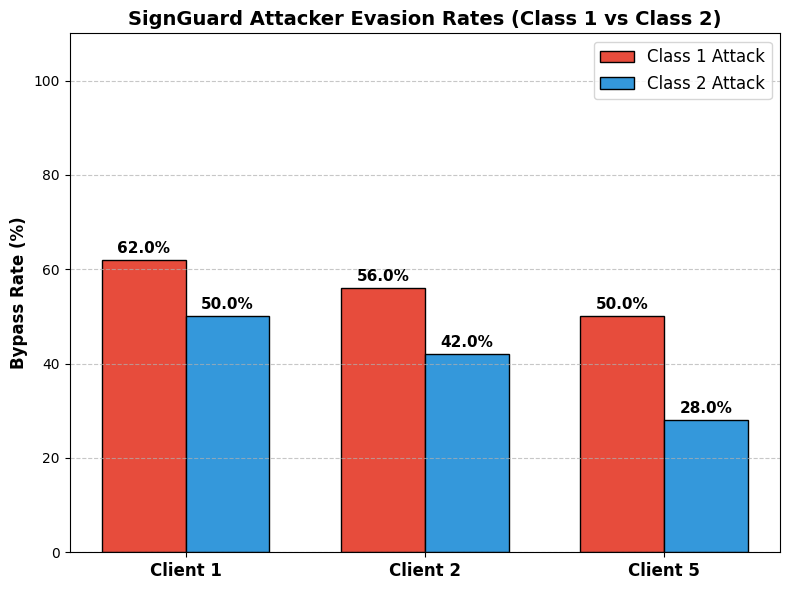

In [8]:
import re
import ast
import matplotlib.pyplot as plt
import numpy as np

def parse_sg_logs_for_plot(file_path, malicious_clients=None):
    """
    Parses the SignGuard array formatting logs and returns the raw data 
    (trust counts and total rounds) so it can be plotted.
    """
    if malicious_clients is None:
        malicious_clients = [1, 2, 5]
        
    trust_counts = {c: 0 for c in malicious_clients}
    total_rounds = 0
    
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            log_text = file.read()
            
        # Isolate the Test 2 Attack section specifically for SignGuard
        if "Strategy: SignGuard | Mode: attack" not in log_text:
            print(f"Error: Could not find SignGuard attack section in {file_path}")
            return None, None
            
        attack_section = log_text.split("Strategy: SignGuard | Mode: attack")[1]
        
        # Regex to locate the arrays, e.g. [0, 1, 2, 3, 5, 7, 8]
        pattern = re.compile(r"\[SignGuard\] Trusted clients:\s*(\[[0-9,\s]+\])")
        
        for match in pattern.finditer(attack_section):
            total_rounds += 1
            trusted_list = ast.literal_eval(match.group(1))
            
            for client_id in malicious_clients:
                if client_id in trusted_list:
                    trust_counts[client_id] += 1
                    
        return trust_counts, total_rounds
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None, None

def plot_signguard_evasion(class1_file, class2_file):
    """
    Takes the two SignGuard log files, extracts their bypass rates, 
    and generates a clean side-by-side grouped bar chart.
    """
    res_c1, rounds_c1 = parse_sg_logs_for_plot(class1_file)
    res_c2, rounds_c2 = parse_sg_logs_for_plot(class2_file)

    if not res_c1 or not res_c2:
        print("Missing data. Cannot plot.")
        return

    clients = [1, 2, 5]
    
    # Calculate bypass percentages
    rates_c1 = [(res_c1.get(c, 0) / rounds_c1) * 100 for c in clients]
    rates_c2 = [(res_c2.get(c, 0) / rounds_c2) * 100 for c in clients]
    
    # Set up plotting variables
    x = np.arange(len(clients))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot grouped bars
    rects1 = ax.bar(x - width/2, rates_c1, width, label='Class 1 Attack', color='#e74c3c', edgecolor='black')
    rects2 = ax.bar(x + width/2, rates_c2, width, label='Class 2 Attack', color='#3498db', edgecolor='black')
    
    # Add labels and formatting
    ax.set_ylabel('Bypass Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('SignGuard Attacker Evasion Rates (Class 1 vs Class 2)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Client {c}' for c in clients], fontsize=12, fontweight='bold')
    ax.legend(fontsize=12)
    ax.set_ylim(0, 110) # Leaves room above bars for labels
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Attach percentage values to the top of bars
    ax.bar_label(rects1, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')
    ax.bar_label(rects2, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Run the plot
plot_signguard_evasion('SG-class1-logs.txt', 'SG-class2-logs.txt')